# 基于 OpenCV 的颜色识别
在本章教程中我们会在 OpenCV 的相关功能中加入一些修改帧画面相关的函数，例如模糊，色彩空间转换，腐蚀和膨胀。

## 准备工作
由于产品开机默认会自动运行主程序，主程序会占用摄像头资源，这种情况下是不能使用本教程的，需要结束主程序或禁止主程序自动运行后再重新启动机器人。

这里需要注意的是，由于机器人主程序中使用了多线程且由 service 配置开机自动运行，所以常规的 sudo killall python 的方法通常是不起作用的，所以我们这里介绍禁用主程序自动运行的方法。

如果你已经禁用了机器人主程序的开机自动运行，则不需要执行下面的`结束主程序`章节。

### 结束主程序
1. 点击上方本页面选项卡旁边的 “+”号，会打开一个新的名为 Launcher 的选项卡。
2. 点击 Other 内的 Terminal，打开终端窗口。
3. 在终端窗口内输入 `bash` 后按回车。
4. 现在你可以使用 Bash Shell 来控制机器人了。
5. 输入命令： `systemctl --user stop ugv-app.service`。
6. 在终端页面，命令执行完后，继续该教程的剩余部分。

## 例程
以下代码块可以直接运行：

1. 选中下面的代码块
2. 按 Shift + Enter 运行代码块
3. 观看实时视频窗口
4. 按 `STOP` 关闭实时视频，释放摄像头资源

### 如果运行时不能看到摄像头实时画面
- 需要点击上方的 Kernel - Shut down all kernels
- 关闭本章节选项卡，再次打开
- 点击 `STOP` 释放摄像头资源后重新运行代码块
- 重启设备

### 运行

我们在例程中默认检测绿色小球，确保画面背景中没有绿色物体影响颜色识别功能，你也可以通过二次开发来更改检测颜色（LAB色彩空间）。

ToggleButton(value=False, button_style='danger', description='Stop', icon='square', tooltip='Description')

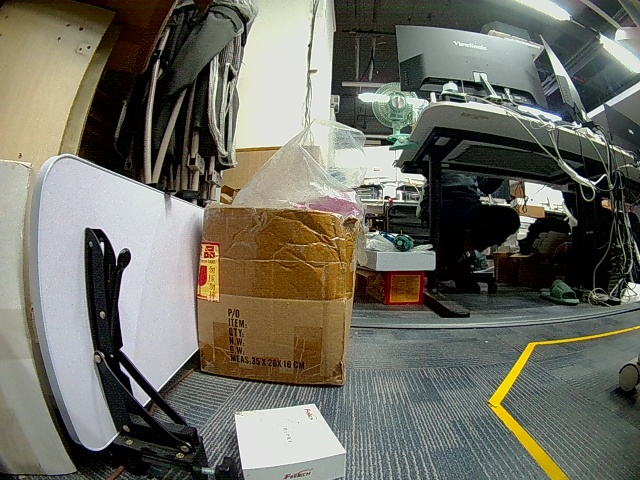

In [ ]:
import cv2
import imutils, math
from picamera2 import Picamera2  # 用于访问 Raspberry Pi Camera 的库
import numpy as np  # 用于数学计算的库
from IPython.display import display, Image  # 用于在 Jupyter Notebook 中显示图像
import ipywidgets as widgets  # 用于创建交互式界面的小部件，如按钮
import threading  # 用于创建新线程，以便异步执行任务

# 创建一个“停止”按钮，用户可以通过点击它来停止视频流
# ================
stopButton = widgets.ToggleButton(
    value=False,
    description='Stop',
    disabled=False,
    button_style='danger', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Description',
    icon='square' # (FontAwesome names without the `fa-` prefix)
)

# 定义显示函数，用于处理视频帧并识别特定颜色的物体
def view(button):
    # 如果你使用的是CSI摄像头 需要取消注释 picam2 这些代码，并注释掉 camera 这些代码
    # 因为新版本的 OpenCV 不再支持 CSI 摄像头（4.9.0.80），你需要使用 picamera2 来获取摄像头画面
    
    # picam2 = Picamera2()  # 创建 Picamera2 的实例
    # 配置摄像头参数，设置视频的格式和大小
    # picam2.configure(picam2.create_video_configuration(main={"format": 'XRGB8888', "size": (640, 480)}))
    # picam2.start()  # 启动摄像头

    camera = cv2.VideoCapture(0) # 创建摄像头实例
    #设置分辨率
    camera.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    camera.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    
    display_handle=display(None, display_id=True)  # 创建显示句柄用于更新显示的图像
    i = 0
    
    # 定义要检测的颜色范围
    color_upper = np.array([255, 110, 195])
    color_lower = np.array([0, 0, 0])

    while True:
        # img = picam2.capture_array() # 从摄像头捕获一帧图像
        _, img = camera.read() # 从摄像头捕获一帧图像
        # frame = cv2.flip(frame, 1) # if your camera reverses your image
        
        cx, cy, w = None, None, None
        img_h, img_w = img.shape[:2]
        overlay_buffer = np.zeros_like(img)
        center_x, center_y = img_w // 2, img_h // 2
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        mask = cv2.inRange(lab, color_lower, color_upper)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            c = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(c)
            if area > 100:  
                ((x, y), radius) = cv2.minEnclosingCircle(c)
                circularity = area / (math.pi * radius * radius)
                if 0.5 < circularity < 1.3:  
                    cx, cy, w = int(x), int(y), int(radius*2)

                    cv2.circle(img, (cx, cy), int(radius), (0, 255, 0), 2)
                    cv2.circle(img, (cx, cy), 3, (255, 0, 0), -1)
                    # print(f'Tracking ball at ({cx}, {cy}), area={area:.1f}, circularity={circularity:.2f}')

        _, frame = cv2.imencode('.jpeg', img)  # 将帧编码为 JPEG 格式
        display_handle.update(Image(data=frame.tobytes()))  # 更新显示的图像
        if stopButton.value==True:  # 检查“停止”按钮是否被按下
            # picam2.close()  # 如果是，则关闭摄像头
            camera.release() # 如果是，则关闭摄像头
            display_handle.update(None)  # 清空显示的内容


# 显示“停止”按钮并启动显示函数的线程
# ================
display(stopButton)
thread = threading.Thread(target=view, args=(stopButton,))
thread.start()